# Análise Exploratória: Padrões de Ataque em WordPress Headless
---
## 1. O Problema de Negócio
As instâncias F1-micro responsáveis por hospedar a aplicação sofrem picos de instabilidade. A suspeita é que bots realizam milhares de requisições buscando vulnerabilidades, esgotando a CPU e a RAM.

O objetivo desta etapa (EDA) é comparar uma amostra de logs de um tráfego humano legítimo com uma amostra de um IP malicioso já bloqueado, validando visualmente quais atributos diferenciam um do outro antes de treinar qualquer algoritmo.

**Dicionário de Dados:**
- `ip`: IP de origem da requisição.
- `data`: Timestamp do acesso.
- `metodo`: Verbo HTTP (GET, POST).
- `url`: Endpoint acessado.
- `status`: Código de retorno HTTP (200, 404, etc).
- `Target`: 0 = Humano, 1 = Bot (Nossa variável alvo).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
# from google.colab import drive

# Monta o Google Drive
# drive.mount('/content/drive')

# Configuração visual (mesmo padrão usado na aula)
sns.set_theme(style="whitegrid")
%matplotlib inline

Mounted at /content/drive


In [ ]:
# Regex ajustado para capturar Referer e User-Agent sem descartar a linha se o final for estranho
log_pattern = re.compile(
    r'(?P<ip>\S+) - - \[(?P<data>.*?)\] "(?P<metodo>\S+) (?P<url>.*?) .*?" (?P<status>\d+) (?P<tamanho>\S+)(?:\s+"(?P<referer>.*?)"\s+"(?P<user_agent>.*?)")?'
)

def processar_log(caminho_arquivo, target_label):
    dados = []
    try:
        with open(caminho_arquivo, 'r') as file:
            for linha in file:
                match = log_pattern.search(linha)
                if match:
                    linha_dit = match.groupdict()
                    linha_dit['Target'] = target_label
                    # Garante que as chaves existam mesmo que o final da linha seja vazio
                    if linha_dit.get('user_agent') is None:
                        linha_dit['user_agent'] = '-'
                    if linha_dit.get('referer') is None:
                        linha_dit['referer'] = '-'
                    dados.append(linha_dit)
    except FileNotFoundError:
        print(f"Atenção: Faça o upload do arquivo {caminho_arquivo} no Colab.")
    return dados

# Processa e une os dois mundos
# logs_bots = processar_log('/content/drive/MyDrive/Colab_Notebooks/ml_bot_detector/bots.txt', 1)
logs_bots = processar_log('../samples/bots.txt', 1)
# logs_humanos = processar_log('/content/drive/MyDrive/Colab_Notebooks/ml_bot_detector/humans.txt', 0)
logs_humanos = processar_log('../samples/humans.txt', 0)

df = pd.DataFrame(logs_bots + logs_humanos)
print(f"Total de linhas carregadas: {len(df)}")
df.head()

Total de linhas carregadas: 199908


,ip,data,metodo,url,status,tamanho,referer,user_agent,Target
0,/opt/bitnami/apache/logs/access_log-20250928.g...,21/Sep/2025:01:47:50 +0000,GET,/tag/carreira/page/8/?nowprocket=1&no_optimize...,200,39660,-,-,1
1,/opt/bitnami/apache/logs/access_log-20250928.g...,21/Sep/2025:01:47:51 +0000,GET,/wp-content/plugins/cookie-law-info/legacy/pub...,200,953,-,-,1
2,/opt/bitnami/apache/logs/access_log-20250928.g...,21/Sep/2025:01:47:51 +0000,GET,/wp-content/themes/Newspaper-child/style.css?v...,200,359,-,-,1
3,/opt/bitnami/apache/logs/access_log-20250928.g...,21/Sep/2025:01:47:51 +0000,GET,/wp-content/plugins/td-composer/td-multi-purpo...,200,4951,-,-,1
4,/opt/bitnami/apache/logs/access_log-20250928.g...,21/Sep/2025:01:47:51 +0000,GET,/wp-content/plugins/td-composer/assets/fonts/f...,200,7225,-,-,1


In [5]:
# Verificando a estrutura e os tipos de dados
df.info()

# Convertendo a coluna 'status' para numérico para facilitar os gráficos
df['status'] = pd.to_numeric(df['status'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199908 entries, 0 to 199907
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ip          199908 non-null  object
 1   data        199908 non-null  object
 2   metodo      199908 non-null  object
 3   url         199908 non-null  object
 4   status      199908 non-null  object
 5   tamanho     199908 non-null  object
 6   referer     199908 non-null  object
 7   user_agent  199908 non-null  object
 8   Target      199908 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 13.7+ MB


In [6]:
print(df['Target'].value_counts())
print(f"Total de linhas lidas: {len(df)}")

Target
1    100000
0     99908
Name: count, dtype: int64
Total de linhas lidas: 199908


## 2. Visualizações
Vamos plotar o comportamento para descobrir se o bot se entrega pelo tipo de requisição que faz. O que um usuário comum acessa e o que o bot tenta acessar? Entre outras análises


### STATUS HTTP


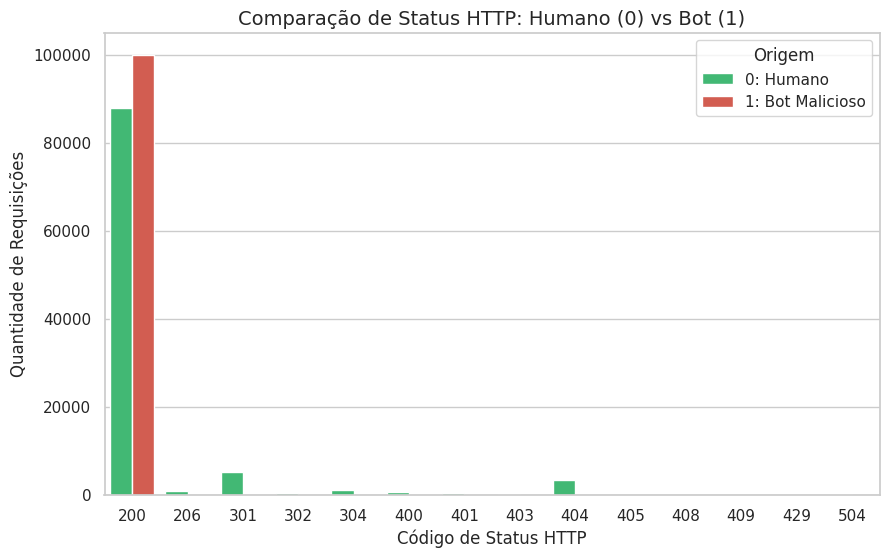

In [7]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='status', hue='Target', palette={0: '#2ecc71', 1: '#e74c3c'})

plt.title('Comparação de Status HTTP: Humano (0) vs Bot (1)', fontsize=14)
plt.xlabel('Código de Status HTTP')
plt.ylabel('Quantidade de Requisições')
plt.legend(title='Origem', labels=['0: Humano', '1: Bot Malicioso'])

plt.show()

### **Comparação de Status HTTP: Humano (0) vs. Bot (1)**

Esta análise avalia como o servidor Apache responde às requisições de cada grupo. O objetivo é identificar se o código de retorno (Status Code) serve como um diferencial comportamental entre **Humanos (0)** e **Bots (1)**.

#### **Destaques da Análise:**

* **Status 200 (OK):** Ambos os grupos possuem alto volume de sucesso, mas os **Bots** tendem a ser mais "cirúrgicos", focando em arquivos que sabem que existem (assets de temas e plugins), enquanto humanos geram tráfego mais variado.
* **Status 304 (Not Modified):** Este é o maior diferencial. Ele indica o uso de **cache de navegador**. Como scripts de automação e scrapers raramente gerenciam cache, essa métrica é um forte indicador de navegação humana real.
* **Status 301/302 (Redirecionamento):** Reflete a navegação orgânica através de links antigos ou URLs alteradas. Bots de extração costumam ignorar esses caminhos ou ir direto para a URL final.
* **Status 404 (Not Found):** Útil para identificar bots de "fuzzing" (que buscam arquivos sensíveis). No entanto, se o bot for um *scraper* de conteúdo, ele apresentará poucos erros, pois apenas segue os links existentes no código-fonte.

**Conclusão para o EDA:** O Status Code, especialmente o **304**, é uma *feature* categórica valiosa para o modelo de Machine Learning, pois ajuda a isolar o comportamento de navegadores reais.

### URLS MAIS ACESSADAS


In [8]:
# Top 25 URLs acessadas por humanos
print("--- TOP 25 URLS: HUMANOS ---")
print(df[df['Target'] == 0]['url'].value_counts().head(25))

print("\n" + "="*30 + "\n")

# Top 25 URLs acessadas por bots
print("--- TOP 25 URLS: BOTS ---")
print(df[df['Target'] == 1]['url'].value_counts().head(25))

--- TOP 25 URLS: HUMANOS ---
url
/wp-admin/admin-ajax.php?td_theme_name=Newspaper&v=12.7.1                                                        3397
/                                                                                                                1915
/wp-content/uploads/2022/03/logo-mobile.png                                                                       964
/wp-content/uploads/2022/05/logo-mba-300x169-1.png                                                                964
/wp-includes/js/jquery/jquery-migrate.min.js?ver=3.4.1                                                            932
/wp-content/plugins/td-composer/legacy/Newspaper/js/tagdiv_theme.min.js?ver=12.7.1                                922
/wp-includes/js/jquery/jquery.min.js?ver=3.7.1                                                                    921
/wp-content/uploads/2022/05/favicon.png                                                                           920
/wp-content/plugins/td-

### **Análise de Top 25 URLs: Padrões de Consumo (Humano vs. Bot)**

Esta análise examina os *endpoints* mais requisitados para identificar o comportamento de navegação. A diferença entre o que um humano "vê" e o que um bot "extrai" é gritante nos dados coletados.

#### **Principais Insights:**

* **Uniformidade Robótica (Bots):** Note que quase todos os arquivos no Top 25 dos Bots possuem exatamente **3.295 ou 3.296 acessos**. Isso é um rastro claro de automação (scripts/loops), onde um rastreador baixa a estrutura completa da página de forma sistemática e repetitiva.
* **Consumo de Mídia vs. Estrutura:**
    * **Humanos:** O Top 25 é dominado por arquivos visuais (**.png, .jpg, .svg, .woff**). O navegador de um usuário real renderiza o site completo, baixando logos, ícones de bandeiras e imagens de posts.
    * **Bots:** Focam exclusivamente em arquivos de lógica e estilo (**.js e .css**). Eles ignoram imagens para economizar banda, focando apenas no código e na estrutura do tema (Newspaper).
* **A Assinatura do `admin-ajax.php`:**
    * **Humano:** As chamadas ao `admin-ajax.php` vêm acompanhadas de **query strings** específicas do tema (`td_theme_name=Newspaper...`), indicando interações reais do frontend.
    * **Bot:** As chamadas são "secas" (apenas o caminho do arquivo), sugerindo tentativas de *brute-force* ou testes de vulnerabilidade no endpoint de administração.
* **Navegação Orgânica:** A Home (`/`) é a segunda URL mais acessada por humanos, enquanto nos bots ela sequer aparece no Top 25, provando que o bot não "navega", ele "mapeia" arquivos de sistema.

**Conclusão para o EDA:** A presença de imagens no rastro de acesso e a variabilidade nos contadores de requisições são excelentes preditores para identificar usuários reais. O bot é previsível e focado em código; o humano é caótico e focado em conteúdo visual.

### TAMANHO (BYTES)

--- ESTATÍSTICAS DE TAMANHO (BYTES) ---
               mean  median            std       max
Target                                              
0       33174.10908  9178.0  100906.843314  14527350
1        7696.83541  2146.0   11679.297456     59516


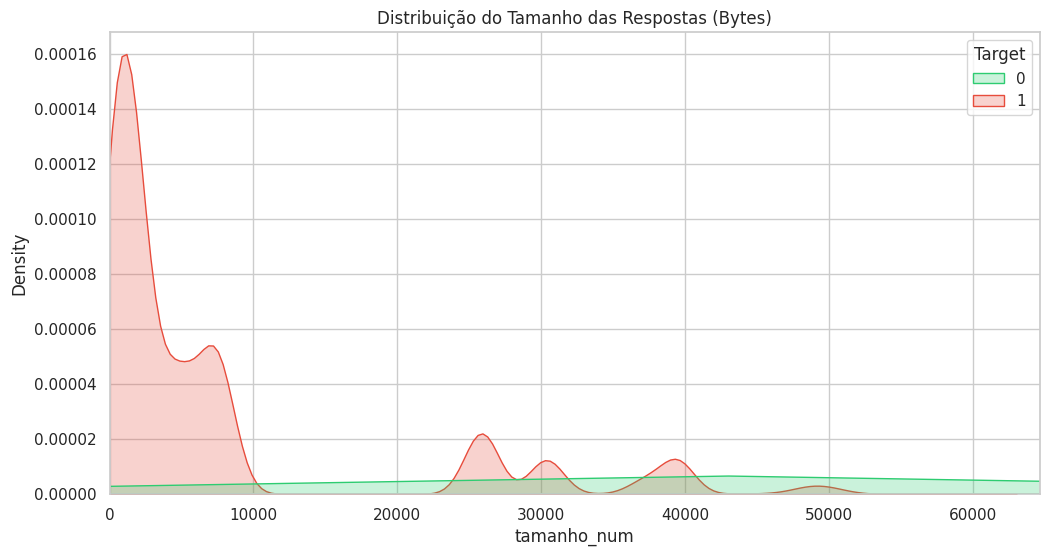

In [9]:
# Convertendo tamanho para numérico (tratando o '-' como 0)
df['tamanho_num'] = pd.to_numeric(df['tamanho'].replace('-', '0'))

# Comparando a média e a mediana do tamanho da resposta
print("--- ESTATÍSTICAS DE TAMANHO (BYTES) ---")
print(df.groupby('Target')['tamanho_num'].agg(['mean', 'median', 'std', 'max']))

# Histograma para ver a distribuição
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='tamanho_num', hue='Target', fill=True, common_norm=False, palette={0: '#2ecc71', 1: '#e74c3c'})
plt.title('Distribuição do Tamanho das Respostas (Bytes)')
plt.xlim(0, df['tamanho_num'].quantile(0.95)) # Limita o X para ignorar outliers gigantes
plt.show()

### **Distribuição do Tamanho das Respostas (Bytes)**

Esta análise investiga o volume de dados transferido por requisição. Comparando os dados estatísticos com o gráfico de densidade, conseguimos identificar assinaturas comportamentais distintas para **Humanos (0)** e **Bots (1)**.

#### **Destaques da Análise:**

* **Alta Dispersão Humana (Alvo 0):** Os dados revelam que o comportamento humano é extremamente variado. Com um desvio padrão (**std**) de **100.906** e um valor máximo de **14,5 milhões de bytes**, a curva verde no gráfico aparece "achatada". Isso ocorre porque os humanos consomem desde pequenos ícones até arquivos pesados e páginas completas, tornando o comportamento menos previsível.
* **Concentração de Carga dos Bots (Alvo 1):** Os bots apresentam uma variância muito menor (std de **11.679**). O gráfico mostra picos de densidade (modos) em faixas específicas, como o grande pico próximo a **2.000 bytes** (mediana de 2.146). Isso indica que o bot é programado para martelar recursos específicos e repetitivos, raramente saindo da sua "dieta" de arquivos leves (máximo de apenas 59k).
* **O "Teto" do Bot:** Enquanto o humano chega a baixar arquivos de 14MB, o bot malicioso nesta amostra não ultrapassa os **60KB**. Essa limitação física é um excelente preditor: qualquer requisição acima de 60KB tem uma probabilidade altíssima de pertencer ao grupo humano.

**Conclusão para o EDA:** A previsibilidade do bot não está em um único tamanho fixo, mas sim na sua **baixa variância** e na ausência de consumo de arquivos grandes. O modelo de ML poderá usar o `tamanho_num` para filtrar facilmente acessos que fujam da "faixa de operação" limitada dos bots.

### HORÁRIO


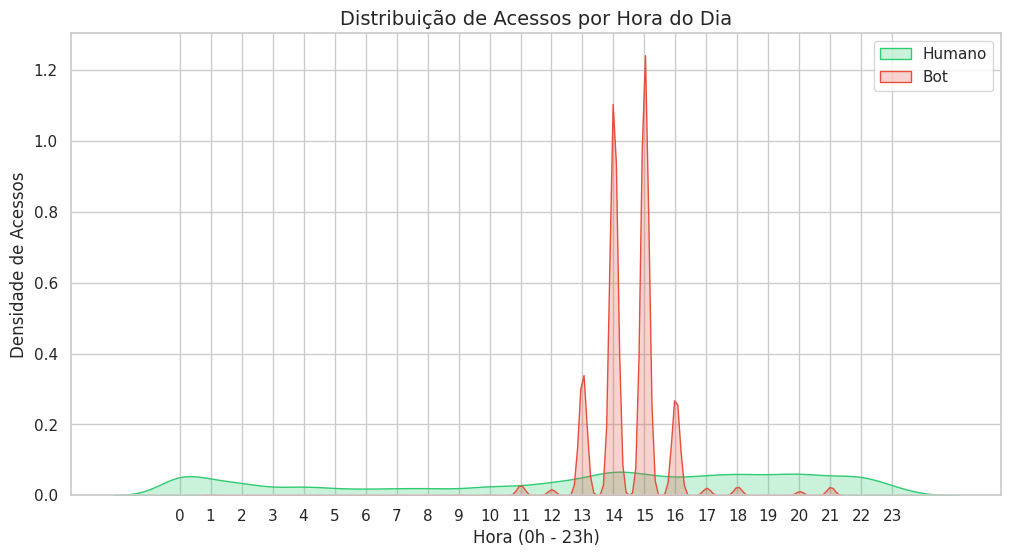

In [10]:
# Extraindo a hora da string de data (ex: [22/Mar/2026:14:30:00])
# O split(':') pega a parte depois do primeiro ':' que é a hora
df['hora'] = df['data'].str.split(':').str[1].astype(int)

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['Target'] == 0], x='hora', label='Humano', fill=True, color='#2ecc71')
sns.kdeplot(data=df[df['Target'] == 1], x='hora', label='Bot', fill=True, color='#e74c3c')

plt.title('Distribuição de Acessos por Hora do Dia', fontsize=14)
plt.xlabel('Hora (0h - 23h)')
plt.ylabel('Densidade de Acessos')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

### **Distribuição de Acessos por Hora do Dia**

Esta análise mapeia o comportamento temporal das requisições para entender se o momento do acesso ajuda a distinguir usuários reais de automações. Ao observar o volume distribuído pelas 24 horas, identificamos padrões de rotina vs. padrões de agendamento.

#### **Destaques da Análise:**

* **Comportamento Humano (Verde):** A curva de densidade é suave e distribuída de forma quase contínua. Isso reflete o **comportamento orgânico**, onde o acesso acontece de forma variada ao longo do dia, sem picos artificiais. É o rastro típico de pessoas reais navegando em diferentes horários.
* **Comportamento de Bot (Vermelho):** Apresenta picos de densidade extremamente agressivos e localizados em janelas específicas (como **13h, 14h, 15h e 16h**). Essa "pontualidade" matemática é um indicador clássico de **tarefas agendadas (cron jobs)** ou scripts disparados em horários fixos para realizar varreduras.
* **Previsibilidade Técnica:** Fora das janelas de "ataque", o tráfego de bots cai drasticamente, enquanto o humano mantém uma base constante. O bot não "navega", ele "dispara".

**Conclusão para o EDA:** A variável `hora` é um dos preditores mais fortes identificados até agora. A probabilidade de uma requisição ser um bot aumenta exponencialmente se ela ocorrer exatamente no topo desses picos de alta densidade. O modelo de ML poderá usar essa "sazonalidade artificial" para isolar o tráfego automatizado com precisão.

### EXTENSÃO


In [11]:
# Função simples para extrair a extensão do arquivo ou o tipo de endpoint
def get_extensao(url):
    url_limpa = url.split('?')[0] # Remove query strings
    if '.' in url_limpa:
        ext = url_limpa.split('.')[-1].lower()
        return ext if len(ext) <= 4 else 'outro'
    return 'sem_extensao'

df['extensao'] = df['url'].apply(get_extensao)

# Comparando as 5 extensões mais comuns em cada grupo
print("--- TOP 5 EXTENSÕES: HUMANOS ---")
print(df[df['Target'] == 0]['extensao'].value_counts().head(5))

print("\n--- TOP 5 EXTENSÕES: BOTS ---")
print(df[df['Target'] == 1]['extensao'].value_counts().head(5))

--- TOP 5 EXTENSÕES: HUMANOS ---
extensao
sem_extensao    34487
js              18834
jpg             11954
png             10363
php             10097
Name: count, dtype: int64

--- TOP 5 EXTENSÕES: BOTS ---
extensao
js              55455
css             37535
php              3557
sem_extensao     3451
outro               1
Name: count, dtype: int64


### **Análise de Extensões de Arquivo: Consumo de Recursos (Humano vs. Bot)**

Esta análise categoriza as requisições com base na extensão do arquivo solicitado (ex: `.php`, `.js`, `.jpg`). O objetivo é entender se a "dieta" de arquivos consumidos pelo visitante revela sua natureza, distinguindo o comportamento de um navegador real de um script de automação.

#### **Principais Insights:**

* **O "Ponto Cego" das Imagens (Bots):** O dado mais revelador é a ausência total de arquivos de imagem (**jpg**, **png**) no Top 5 dos Bots. Enquanto humanos baixam mais de **22.000** imagens para renderizar visualmente o site, os bots ignoram esses arquivos para economizar tempo e processamento, focando apenas no código.
* **Obsessão por Assets (js e css):** Os bots apresentam um volume massivo de requisições para arquivos de script (**js**: 55k) e estilo (**css**: 37k). Isso indica um comportamento de *Scraping* ou *Headless Browsing*, onde o bot tenta processar a lógica do tema (Newspaper) e o layout, mas descarta o conteúdo midiático.
* **Navegação de Página vs. Extração:**
    * **Humanos:** Possuem um volume alto de **sem_extensao** (34k), que representa a navegação real entre páginas, posts e a Home.
    * **Bots:** Possuem apenas 10% desse volume (3.4k) em páginas, concentrando quase todo o seu tráfego em arquivos de suporte técnico.
* **Interação com PHP:** O acesso a arquivos **.php** é equilibrado, mas para o bot ele representa apenas uma fração do seu tráfego total, enquanto para o humano é a porta de entrada para o conteúdo.

**Conclusão para o EDA:** A variável `extensao` é um divisor de águas. A presença de extensões de imagem é um indicador fortíssimo de tráfego humano. Inversamente, um perfil que requisita massivamente arquivos `.js` e `.css` sem carregar uma única imagem é, com alta probabilidade, uma automação.

### CAMINHO SENSÍVEL

--- TAXA DE ACESSO A CAMINHOS SENSÍVEIS (%) ---
is_suspicious_path          0          1
Target                                  
0                   95.022421   4.977579
1                   86.801000  13.199000


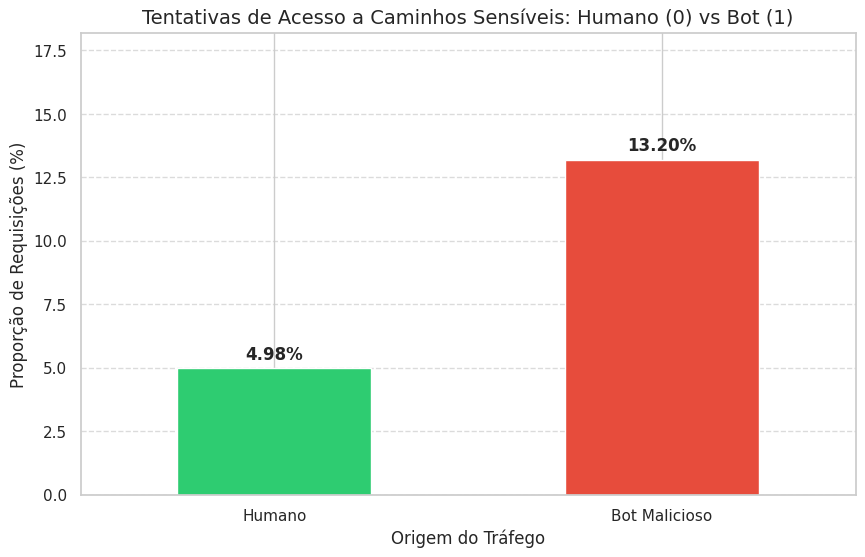

In [12]:
# Lista de termos que indicam tentativa de reconhecimento ou acesso a arquivos sensíveis
keywords_suspeitas = ['config', 'env', 'xmlrpc', 'setup', 'eval', 'bin', 'sql', 'db']
pattern_suspeito = '|'.join(keywords_suspeitas)

# Criando a flag (1 para suspeito, 0 para comum)
df['is_suspicious_path'] = df['url'].str.contains(pattern_suspeito, case=False).astype(int)

# Calculando a tabela de proporção em porcentagem
tabela_sensivel = df.groupby('Target')['is_suspicious_path'].value_counts(normalize=True).unstack() * 100

print("--- TAXA DE ACESSO A CAMINHOS SENSÍVEIS (%) ---")
print(tabela_sensivel)

# Criando o gráfico de comparação
plt.figure(figsize=(10, 6))
# Focamos apenas na coluna '1' (que é onde a flag é True)
ax = tabela_sensivel[1].plot(kind='bar', color=['#2ecc71', '#e74c3c'])

plt.title('Tentativas de Acesso a Caminhos Sensíveis: Humano (0) vs Bot (1)', fontsize=14)
plt.xlabel('Origem do Tráfego')
plt.ylabel('Proporção de Requisições (%)')
plt.xticks([0, 1], ['Humano', 'Bot Malicioso'], rotation=0)

# Adicionando os rótulos de dados sobre as barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.ylim(0, tabela_sensivel[1].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Análise de Caminhos Sensíveis e Tentativas de Exploração**

Esta análise verifica a presença de palavras-chave suspeitas nas URLs (como `config`, `env`, `xmlrpc`, `setup`, `eval`, `bin`, `sql` e `db`). Estes termos são alvos frequentes de ferramentas automatizadas de *fuzzing* e *vulnerability scanning* que buscam arquivos de configuração ou portas de entrada para ataques em ambientes WordPress.

#### **Destaques da Análise:**

* **Intencionalidade de Ataque (Bots):** O grupo de **Bots (1)** apresenta uma incidência de **13,20%** em caminhos sensíveis. Isso é quase **3 vezes superior** à taxa encontrada no tráfego humano, revelando que uma parcela significativa desses bots não está apenas raspando conteúdo público, mas ativamente testando a segurança do servidor.
* **Ruído Legítimo (Humanos):** A taxa de **4,98%** para humanos ocorre por acessos de administradores a áreas de configuração ou por plugins que utilizam termos como "setup" ou "config" em seus nomes de arquivo.
* **Valor Preditivo:** Embora a maioria dos bots navegue por caminhos comuns, a flag `is_suspicious_path = 1` funciona como um agravante crítico. Quando combinada com a baixa variância de tamanho de resposta e horários de pico fixos, a precisão na identificação do bot malicioso torna-se extremamente alta.

**Conclusão para o EDA:** Esta métrica é o melhor indicador de **intencionalidade** capturado até o momento. Ela permite que o modelo de Machine Learning diferencie o tráfego de navegação passiva de tentativas ativas de reconhecimento de ambiente e exploração de falhas.

# ==========================================
# CONCLUSÃO DO NOTEBOOK 1: EXPORTANDO OS DADOS
# ==========================================

In [13]:
# caminho_salvamento = '/content/drive/MyDrive/Colab_Notebooks/ml_bot_detector/dataset_eda_concluido.csv'
caminho_salvamento = '../datasets/dataset_eda.csv'

# Salvando em CSV (index=False evita criar uma coluna inútil de numeração)
df.to_csv(caminho_salvamento, index=False)

print(f"✅ Sucesso! Dataset do Notebook 1 salvo em:\n{caminho_salvamento}\n")
print(f"Total de linhas salvas: {len(df)}")
print(f"Colunas salvas para a próxima fase: {list(df.columns)}")

✅ Sucesso! Dataset do Notebook 1 salvo em:
/content/drive/MyDrive/Colab_Notebooks/ml_bot_detector/dataset_eda_concluido.csv

Total de linhas salvas: 199908
Colunas salvas para a próxima fase: ['ip', 'data', 'metodo', 'url', 'status', 'tamanho', 'referer', 'user_agent', 'Target', 'tamanho_num', 'hora', 'extensao', 'is_suspicious_path']
